Algorithm 1 — Dijkstra

In [1]:
import pandas as pd
import heapq

# Read dataset file
df = pd.read_csv("distance_matrix_small (1).csv", index_col=0)

# Convert dataset to matrix
city_matrix = df.values.tolist()

# Get city names
cities = df.index.tolist()


def dijkstra(matrix, start):
    n = len(matrix)

    # Initialize distances
    distances = [float('inf')] * n
    distances[start] = 0

    # Track visited cities
    visited = [False] * n

    # Priority queue
    pq = [(0, start)]

    while pq:
        current_distance, current_city = heapq.heappop(pq)

        if visited[current_city]:
            continue

        visited[current_city] = True

        # Check neighboring cities
        for neighbor in range(n):

            distance = matrix[current_city][neighbor]

            if distance > 0:

                new_distance = current_distance + distance

                # Update shortest path
                if new_distance < distances[neighbor]:
                    distances[neighbor] = new_distance
                    heapq.heappush(
                        pq,
                        (new_distance, neighbor)
                    )

    return distances


# Start from Riyadh (index 0)
result = dijkstra(city_matrix, 0)

# Print results
print("Shortest distances from", cities[0])

for i in range(len(result)):
    print(f"{cities[i]}: {round(result[i], 2)} km")

Shortest distances from Riyadh
Riyadh: 0 km
Jeddah: 79.11 km
Dammam: 101.76 km
Mecca: 80.75 km
Medina: 61.47 km
Khobar: 40.55 km
Abha: 96.28 km
Tabuk: 78.06 km
Hail: 27.75 km


In [2]:
import time

# ---------- BEST CASE ----------
print("---- Best Case ----")

best_matrix = [row[:3] for row in city_matrix[:3]]

start_time = time.perf_counter()

best_result = dijkstra(best_matrix, 0)

end_time = time.perf_counter()

print("Cities:", cities[:3])
print("Shortest Distances:", best_result)
print(f"Execution Time: {(end_time - start_time)*1000:.4f} ms")


# ---------- AVERAGE CASE ----------
print("\n---- Average Case ----")

avg_matrix = [row[:6] for row in city_matrix[:6]]

start_time = time.perf_counter()

avg_result = dijkstra(avg_matrix, 0)

end_time = time.perf_counter()

print("Cities:", cities[:6])
print("Shortest Distances:", avg_result)
print(f"Execution Time: {(end_time - start_time)*1000:.4f} ms")


# ---------- WORST CASE ----------
print("\n---- Worst Case ----")

start_time = time.perf_counter()

worst_result = dijkstra(city_matrix, 0)

end_time = time.perf_counter()

print("Cities:", cities)
print("Shortest Distances:", worst_result)
print(f"Execution Time: {(end_time - start_time)*1000:.4f} ms")

---- Best Case ----
Cities: ['Riyadh', 'Jeddah', 'Dammam']
Shortest Distances: [0, 79.11154474360372, 101.756895828171]
Execution Time: 0.3838 ms

---- Average Case ----
Cities: ['Riyadh', 'Jeddah', 'Dammam', 'Mecca', 'Medina', 'Khobar']
Shortest Distances: [0, 79.11154474360372, 101.756895828171, 80.75256087266784, 61.47276855663685, 40.55396402636335]
Execution Time: 0.3995 ms

---- Worst Case ----
Cities: ['Riyadh', 'Jeddah', 'Dammam', 'Mecca', 'Medina', 'Khobar', 'Abha', 'Tabuk', 'Hail']
Shortest Distances: [0, 79.11154474360372, 101.756895828171, 80.75256087266784, 61.47276855663685, 40.55396402636335, 96.28392235771888, 78.06021749739811, 27.747517910314595]
Execution Time: 0.6057 ms


Algorithm 2 — Held-Karp Dynamic Programming

In [3]:
import pandas as pd
import math

# Read dataset file
df = pd.read_csv("distance_matrix_small (1).csv", index_col=0)

# Convert to matrix
city_matrix = df.values.tolist()

# Get city names
cities = df.index.tolist()


def tsp_held_karp(matrix):

    n = len(matrix)

    # DP table
    dp = [[math.inf] * n for _ in range(1 << n)]

    # Parent table
    parent = [[-1] * n for _ in range(1 << n)]

    # Start from city 0
    dp[1][0] = 0

    # Iterate through subsets
    for mask in range(1 << n):

        for current_city in range(n):

            if dp[mask][current_city] == math.inf:
                continue

            for next_city in range(n):

                # Skip visited city
                if mask & (1 << next_city):
                    continue

                new_mask = mask | (1 << next_city)

                new_cost = (
                    dp[mask][current_city]
                    + matrix[current_city][next_city]
                )

                # Update minimum cost
                if new_cost < dp[new_mask][next_city]:
                    dp[new_mask][next_city] = new_cost
                    parent[new_mask][next_city] = current_city

    # Final state
    full_mask = (1 << n) - 1

    min_cost = math.inf
    last_city = -1

    # Return to starting city
    for city in range(1, n):

        total_cost = (
            dp[full_mask][city]
            + matrix[city][0]
        )

        if total_cost < min_cost:
            min_cost = total_cost
            last_city = city

    # Rebuild path
    route = []
    mask = full_mask

    while last_city != -1:
        route.append(last_city)

        temp = parent[mask][last_city]
        mask ^= (1 << last_city)
        last_city = temp

    route.reverse()
    route.append(0)

    city_route = [cities[i] for i in route]

    return min_cost, city_route


# Run algorithm
distance, route = tsp_held_karp(city_matrix)

# Print result
print("Optimal Distance:", round(distance, 2))
print("Optimal Route:")
print(" > ".join(route))

Optimal Distance: 309.21
Optimal Route:
Riyadh > Hail > Medina > Jeddah > Mecca > Dammam > Abha > Tabuk > Khobar > Riyadh


In [4]:
import time

# ---------- BEST CASE ----------
print("---- Best Case ----")

best_matrix = [row[:3] for row in city_matrix[:3]]

start_time = time.perf_counter()

distance, route = tsp_held_karp(best_matrix)

end_time = time.perf_counter()

print("Cities:", cities[:3])
print("Optimal Distance:", round(distance, 2))
print("Route:", " > ".join(route))
print(f"Execution Time: {(end_time - start_time)*1000:.4f} ms")


# ---------- AVERAGE CASE ----------
print("\n---- Average Case ----")

avg_matrix = [row[:6] for row in city_matrix[:6]]

start_time = time.perf_counter()

distance, route = tsp_held_karp(avg_matrix)

end_time = time.perf_counter()

print("Cities:", cities[:6])
print("Optimal Distance:", round(distance, 2))
print("Route:", " > ".join(route))
print(f"Execution Time: {(end_time - start_time)*1000:.4f} ms")


# ---------- WORST CASE ----------
print("\n---- Worst Case ----")

start_time = time.perf_counter()

distance, route = tsp_held_karp(city_matrix)

end_time = time.perf_counter()

print("Cities:", cities)
print("Optimal Distance:", round(distance, 2))
print("Route:", " > ".join(route))
print(f"Execution Time: {(end_time - start_time)*1000:.4f} ms")

---- Best Case ----
Cities: ['Riyadh', 'Jeddah', 'Dammam']
Optimal Distance: 203.54
Route: Riyadh > Dammam > Jeddah > Riyadh
Execution Time: 0.2181 ms

---- Average Case ----
Cities: ['Riyadh', 'Jeddah', 'Dammam', 'Mecca', 'Medina', 'Khobar']
Optimal Distance: 235.69
Route: Riyadh > Khobar > Medina > Jeddah > Dammam > Mecca > Riyadh
Execution Time: 0.8515 ms

---- Worst Case ----
Cities: ['Riyadh', 'Jeddah', 'Dammam', 'Mecca', 'Medina', 'Khobar', 'Abha', 'Tabuk', 'Hail']
Optimal Distance: 309.21
Route: Riyadh > Hail > Medina > Jeddah > Mecca > Dammam > Abha > Tabuk > Khobar > Riyadh
Execution Time: 17.5593 ms


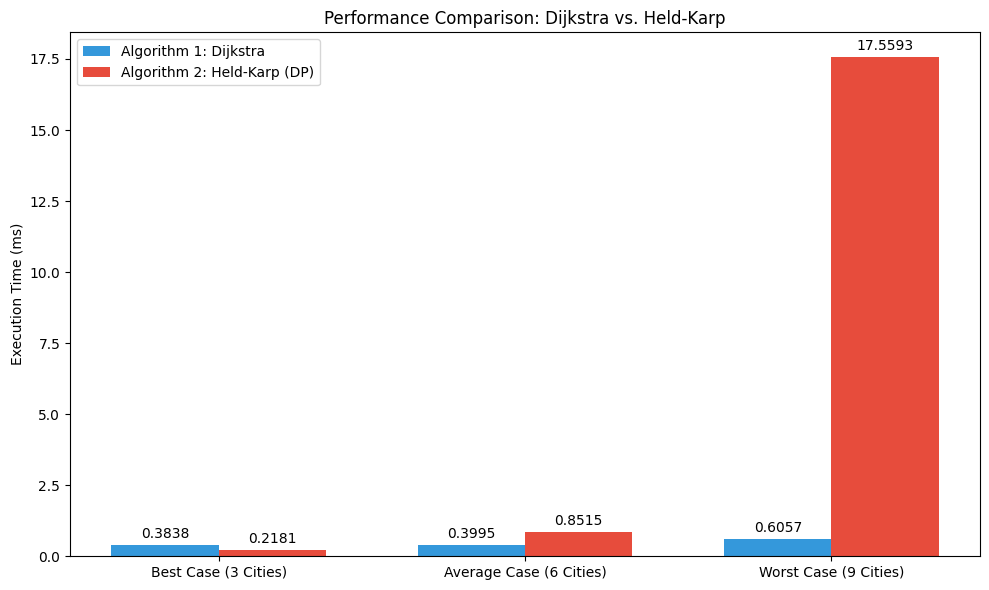

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

scenarios = ['Best Case (3 Cities)', 'Average Case (6 Cities)', 'Worst Case (9 Cities)']
dijkstra_times = [0.3838 , 0.3995 , 0.6057]  # Algorithm 1 
held_karp_times = [0.2181, 0.8515, 17.5593]  # Algorithm 2 

x = np.arange(len(scenarios))  
width = 0.35  

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, dijkstra_times, width, label='Algorithm 1: Dijkstra', color='#3498db')
rects2 = ax.bar(x + width/2, held_karp_times, width, label='Algorithm 2: Held-Karp (DP)', color='#e74c3c')

ax.set_ylabel('Execution Time (ms)')
ax.set_title('Performance Comparison: Dijkstra vs. Held-Karp')
ax.set_xticks(x)
ax.set_xticklabels(scenarios)
ax.legend()

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), 
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()

plt.savefig('performance_comparison.png')
plt.show()

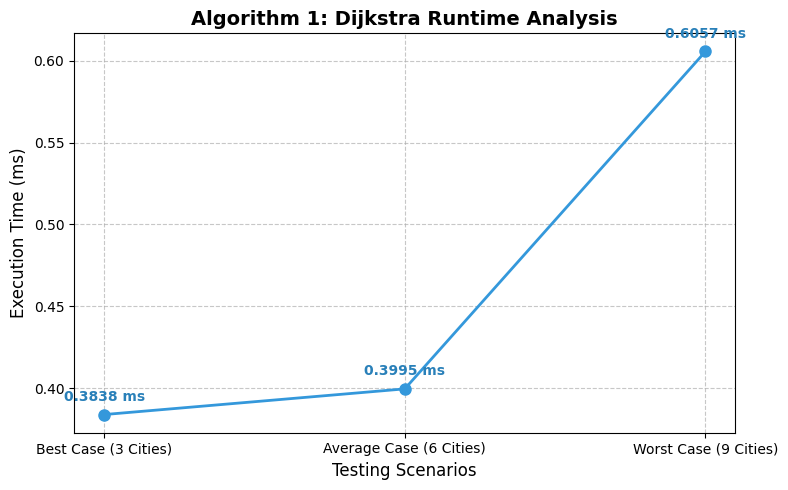

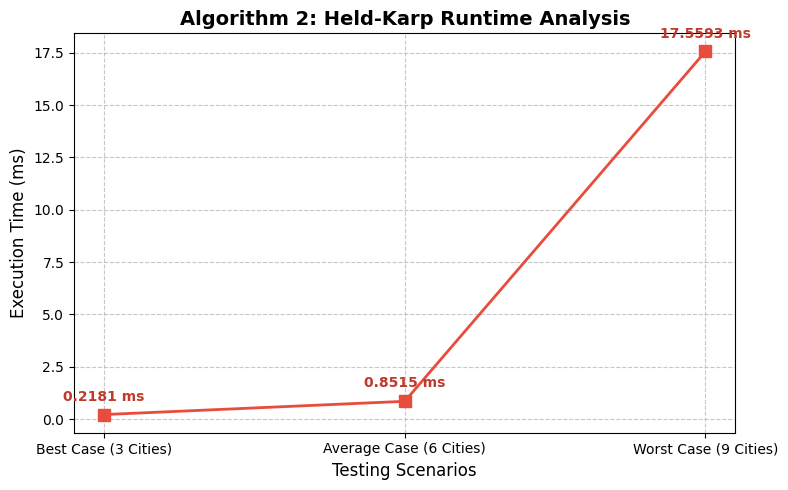

In [ ]:
import matplotlib.pyplot as plt

cities_count = [3, 6, 9]
labels = ['Best Case (3 Cities)', 'Average Case (6 Cities)', 'Worst Case (9 Cities)']

dijkstra_times = [0.3838 , 0.3995 , 0.6057] 
held_karp_times = [0.2181, 0.8515, 17.5593]


# --- Graph 1: Algorithm 1 (Dijkstra) Line Chart ---
plt.figure(figsize=(8, 5))
plt.plot(cities_count, dijkstra_times, marker='o', linestyle='-', color='#3498db', linewidth=2, markersize=8)
plt.title('Algorithm 1: Dijkstra Runtime Analysis', fontsize=14, fontweight='bold')
plt.xlabel('Testing Scenarios', fontsize=12)
plt.ylabel('Execution Time (ms)', fontsize=12)
plt.xticks(cities_count, labels)
plt.grid(True, linestyle='--', alpha=0.7)

for i, txt in enumerate(dijkstra_times):
    plt.annotate(f'{txt:.4f} ms', (cities_count[i], dijkstra_times[i]), 
                 textcoords="offset points", xytext=(0,10), ha='center', fontweight='bold', color='#2980b9')

plt.tight_layout()
plt.savefig('dijkstra_line_chart.png')
plt.show()

# --- Graph 2: Algorithm 2 (Held-Karp) Line Chart ---
plt.figure(figsize=(8, 5))
plt.plot(cities_count, held_karp_times, marker='s', linestyle='-', color='#e74c3c', linewidth=2, markersize=8)
plt.title('Algorithm 2: Held-Karp Runtime Analysis', fontsize=14, fontweight='bold')
plt.xlabel('Testing Scenarios', fontsize=12)
plt.ylabel('Execution Time (ms)', fontsize=12)
plt.xticks(cities_count, labels)
plt.grid(True, linestyle='--', alpha=0.7)

for i, txt in enumerate(held_karp_times):
    plt.annotate(f'{txt:.4f} ms', (cities_count[i], held_karp_times[i]), 
                 textcoords="offset points", xytext=(0,10), ha='center', fontweight='bold', color='#c0392b')

plt.tight_layout()
plt.savefig('held_karp_line_chart.png')
plt.show()

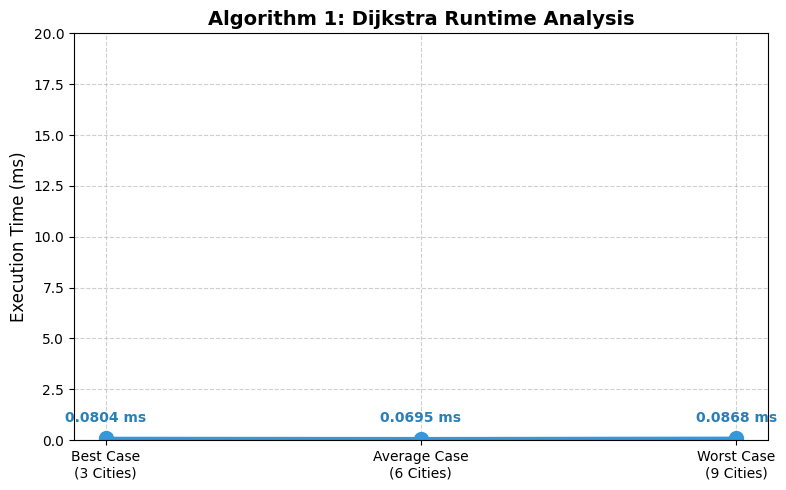

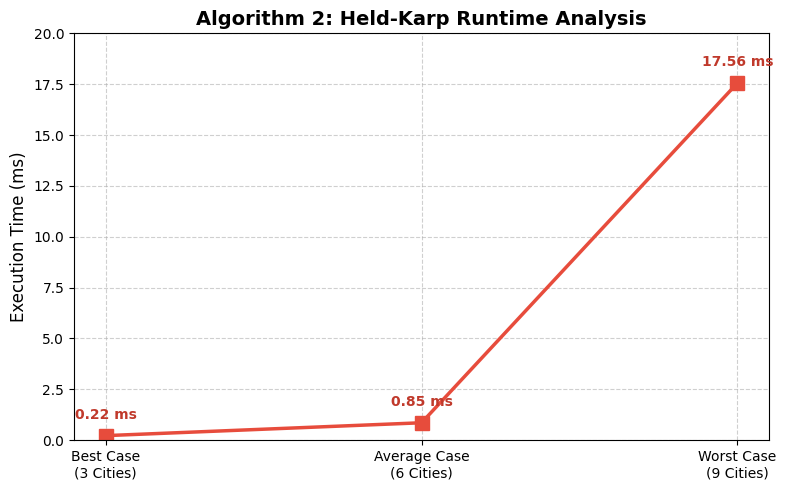

In [11]:
import matplotlib.pyplot as plt

# 1. Data from your project results
scenarios = ['Best Case\n(3 Cities)', 'Average Case\n(6 Cities)', 'Worst Case\n(9 Cities)']
cities_count = [3, 6, 9]

# Execution times (ms) from your specific runs
dijkstra_times = [0.0804, 0.0695, 0.0868] 
held_karp_times = [0.2181, 0.8515, 17.5593]

# 2. Unified Scale (setting the same Y-axis limit for both)
# We use 20ms as the limit since your highest value is ~17.5ms
y_limit = 20 

# --- GRAPH 1: Algorithm 1 (Dijkstra) ---
plt.figure(figsize=(8, 5))
plt.plot(scenarios, dijkstra_times, marker='o', linestyle='-', color='#3498db', linewidth=2.5, markersize=10)

plt.ylim(0, y_limit) # Setting unified scale
plt.title('Algorithm 1: Dijkstra Runtime Analysis', fontsize=14, fontweight='bold')
plt.ylabel('Execution Time (ms)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Add data labels
for i, txt in enumerate(dijkstra_times):
    plt.annotate(f'{txt:.4f} ms', (scenarios[i], dijkstra_times[i]), 
                 textcoords="offset points", xytext=(0,12), ha='center', fontweight='bold', color='#2980b9')

plt.tight_layout()
plt.savefig('dijkstra_unified.png')
plt.show()

# --- GRAPH 2: Algorithm 2 (Held-Karp) ---
plt.figure(figsize=(8, 5))
plt.plot(scenarios, held_karp_times, marker='s', linestyle='-', color='#e74c3c', linewidth=2.5, markersize=10)

plt.ylim(0, y_limit) # Setting unified scale
plt.title('Algorithm 2: Held-Karp Runtime Analysis', fontsize=14, fontweight='bold')
plt.ylabel('Execution Time (ms)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Add data labels
for i, txt in enumerate(held_karp_times):
    plt.annotate(f'{txt:.2f} ms', (scenarios[i], held_karp_times[i]), 
                 textcoords="offset points", xytext=(0,12), ha='center', fontweight='bold', color='#c0392b')

plt.tight_layout()
plt.savefig('held_karp_unified.png')
plt.show()